# Thesis Defense: Dual-Task Model Inputs & Outputs

Presentation-quality panels showing what the model sees and what it produces.

- **Inputs panel**: 3 magnitude frames (temporal context) + 3 velocity components
- **Outputs panel**: predicted enhanced cine magnitude

In [1]:
import platform
from pathlib import Path

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from vascular_superenhancement.utils.path_config import load_path_config

config_name = "local_mac" if platform.system() == "Darwin" else "all_patients"
pc = load_path_config(config_name)

PATIENT_DATA_DIR = pc.working_dir / "patient_data"
DS_FOLDER = "downsampled_full_fov_128x128x64"
INFERENCE_RUN = "glowing-microwave_epoch-69"
INFERENCE_ROOT = Path.cwd().parents[1] / "working_dir" / "inference" / INFERENCE_RUN

PID = "Diecudey"
FRAME = 4

OUTPUT_DIR = Path("thesis_figures")
OUTPUT_DIR.mkdir(exist_ok=True)

patient_dir = PATIENT_DATA_DIR / PID
ds_root = patient_dir / "nifti" / DS_FOLDER
pred_root = INFERENCE_ROOT / PID

print(f"Downsampled root: {ds_root}")
print(f"Exists: {ds_root.exists()}")
print(f"Inference root:  {pred_root}")
print(f"Exists: {pred_root.exists()}")

Found project root at: /home/ayeluru/vascular-superenhancement-4d-flow
Downsampled root: /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/all_patients/patient_data/Diecudey/nifti/downsampled_full_fov_128x128x64
Exists: True
Inference root:  /home/ayeluru/vascular-superenhancement-4d-flow/working_dir/inference/glowing-microwave_epoch-69/Diecudey
Exists: True


In [2]:
COMPONENTS = ["vx", "vy", "vz"]
COMP_LABELS = {"vx": r"$V_x$", "vy": r"$V_y$", "vz": r"$V_z$"}


def load_vol(path: Path) -> np.ndarray:
    return nib.load(str(path)).get_fdata(dtype=np.float32)


def axial_slice(vol: np.ndarray, z_idx: int | None = None) -> np.ndarray:
    if z_idx is None:
        z_idx = vol.shape[2] // 2
    return vol[:, :, z_idx]


z_idx = 29
MAG_VMAX_SCALE = 2.0  # widen window to match PACS-like display

# === INPUTS ===
# Magnitude frames: t-1, t, t+1
mag_frames = {}
for offset, label in [(-1, "t-1"), (0, "t"), (1, "t+1")]:
    frame_idx = FRAME + offset
    path = ds_root / "4d_flow_mag" / f"4d_flow_mag_{PID}_frame_{frame_idx:02d}.nii.gz"
    vol = load_vol(path)
    if z_idx is None:
        z_idx = vol.shape[2] // 2
    mag_frames[label] = axial_slice(vol, z_idx)

# Velocity components (uncorrected)
vel_uncorr = {}
for comp in COMPONENTS:
    path = ds_root / f"4d_flow_{comp}" / f"4d_flow_{comp}_{PID}_frame_{FRAME:02d}.nii.gz"
    vel_uncorr[comp] = axial_slice(load_vol(path), z_idx)

# === OUTPUT (predicted enhanced magnitude at 128x128x64) ===
pred_mag = axial_slice(
    load_vol(pred_root / "raw_predictions" / f"pred_mag_t{FRAME:02d}.nii.gz"),
    z_idx,
)

# === Scaling ===
all_vel = np.concatenate([vel_uncorr[c].ravel() for c in COMPONENTS])
vel_scale = np.percentile(np.abs(all_vel), 99)

print(f"z_idx:      {z_idx}")
print(f"vel_scale:  ±{vel_scale:.1f}")

z_idx:      29
vel_scale:  ±1527.5


Saved: thesis_figures/model_inputs_Diecudey.png


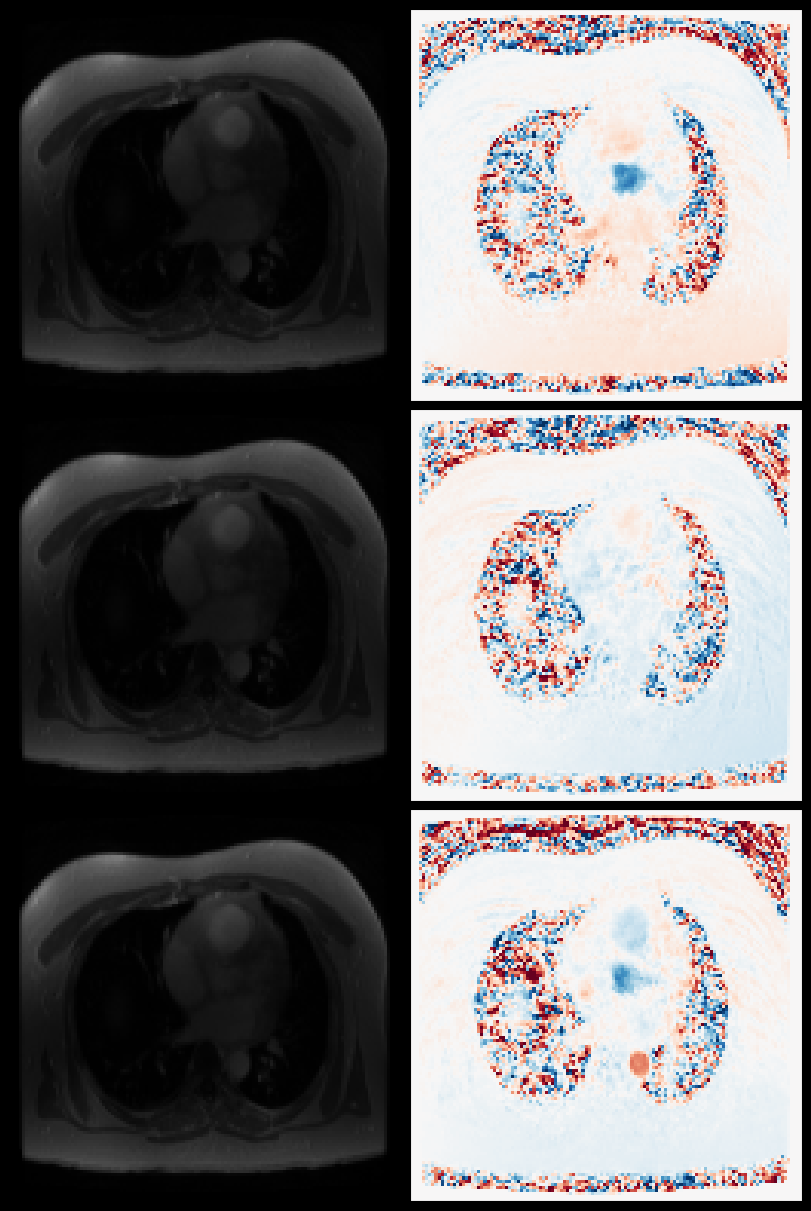

In [3]:
vel_cmap = plt.cm.RdBu_r.copy()
vel_cmap.set_bad("black")

# ─── INPUTS: 3 rows × 2 cols ────────────────────────────────────────
# Col 0 (Mag):      t+1, t, t-1  (top to bottom)
# Col 1 (Velocity): Vx,  Vy, Vz  (top to bottom)
mag_order = ["t+1", "t", "t-1"]

fig, axes = plt.subplots(3, 2, figsize=(8, 12), constrained_layout=True)
fig.patch.set_facecolor("black")

for row, label in enumerate(mag_order):
    axes[row, 0].imshow(mag_frames[label].T, origin="upper", cmap="gray",
                        vmin=0, vmax=mag_frames[label].max() * MAG_VMAX_SCALE)

for row, comp in enumerate(COMPONENTS):
    axes[row, 1].imshow(
        vel_uncorr[comp].T, origin="upper", cmap=vel_cmap,
        vmin=-vel_scale, vmax=vel_scale,
    )

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"model_inputs_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

Saved: thesis_figures/model_outputs_Diecudey.png


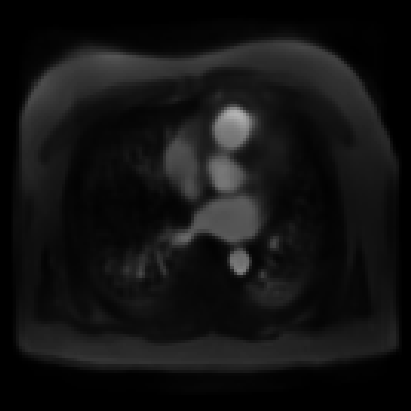

In [4]:
# ─── OUTPUT: predicted enhanced magnitude ────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(4, 4), constrained_layout=True)
fig.patch.set_facecolor("black")

ax.imshow(pred_mag.T, origin="upper", cmap="gray", vmin=0, vmax=1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"model_outputs_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

Saved: thesis_figures/model_gt_Diecudey.png


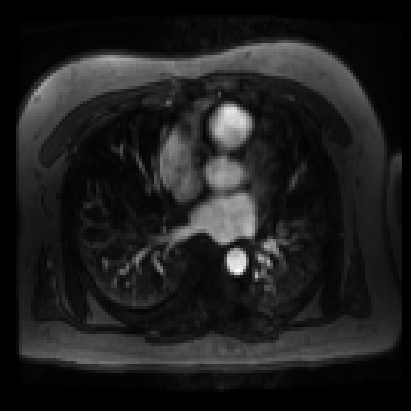

In [5]:
# ─── GROUND TRUTH: 3D cine ───────────────────────────────────────────
cine_gt = axial_slice(
    load_vol(ds_root / "3d_cine" / f"3d_cine_{PID}_frame_{FRAME:02d}.nii.gz"),
    z_idx,
)

fig, ax = plt.subplots(1, 1, figsize=(4, 4), constrained_layout=True)
fig.patch.set_facecolor("black")

ax.imshow(cine_gt.T, origin="upper", cmap="gray", vmin=0, vmax=cine_gt.max())
ax.set_xticks([])
ax.set_yticks([])
ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"model_gt_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

Saved: thesis_figures/si_cnr_Bomatog.png


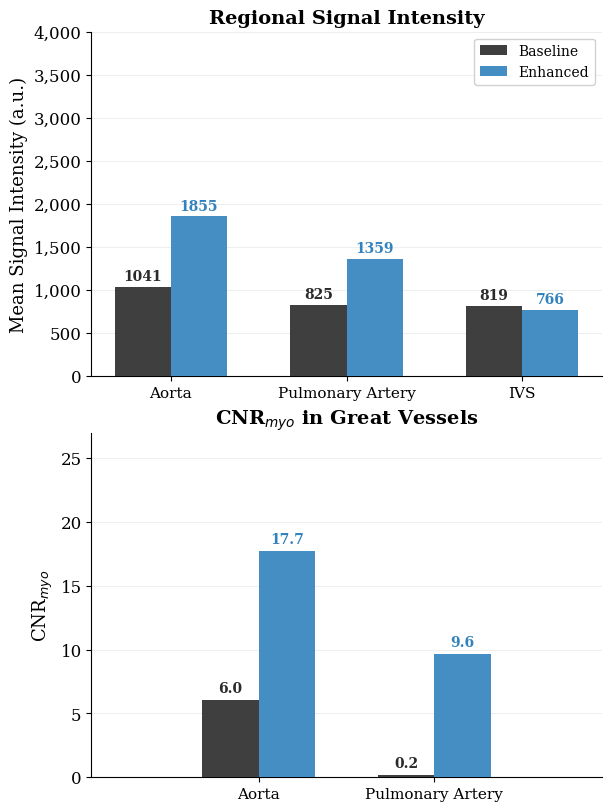

Saved: thesis_figures/si_cnr_Gueshifa.png


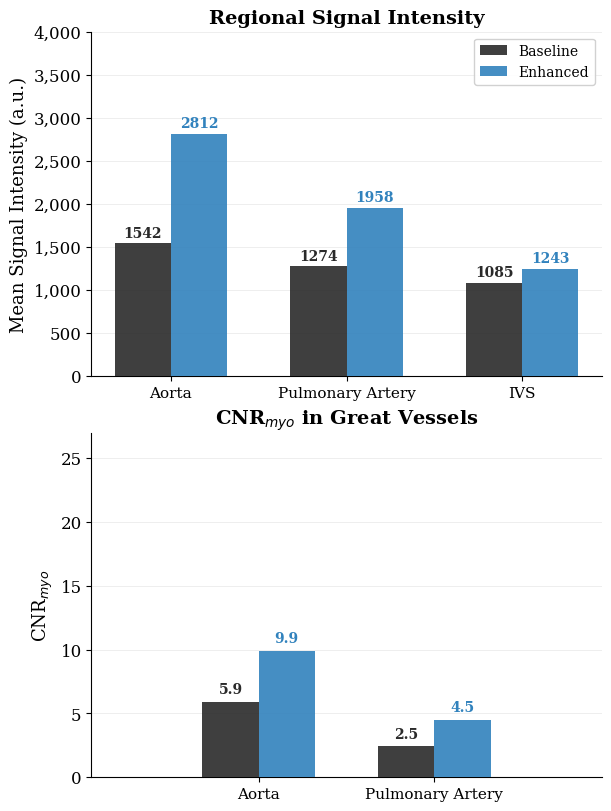

Saved: thesis_figures/si_cnr_Diecudey.png


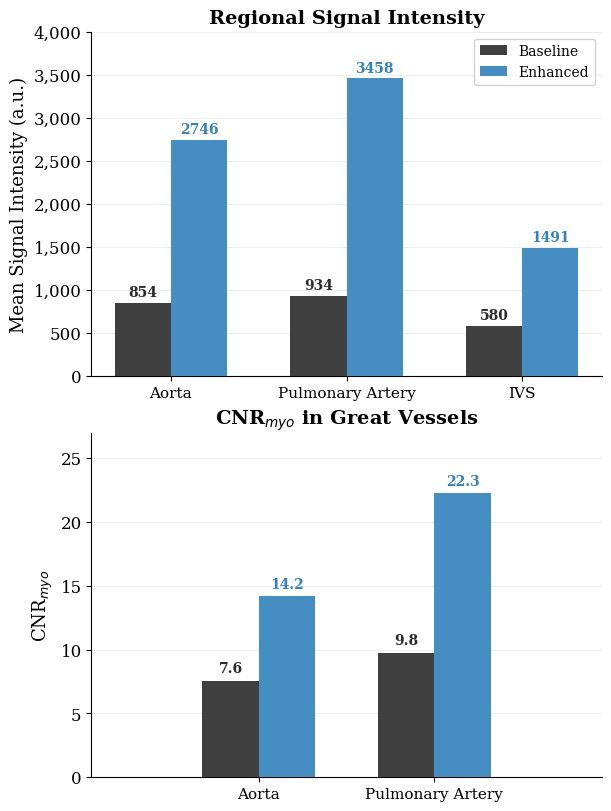

Saved: thesis_figures/si_cnr_Grequafie.png


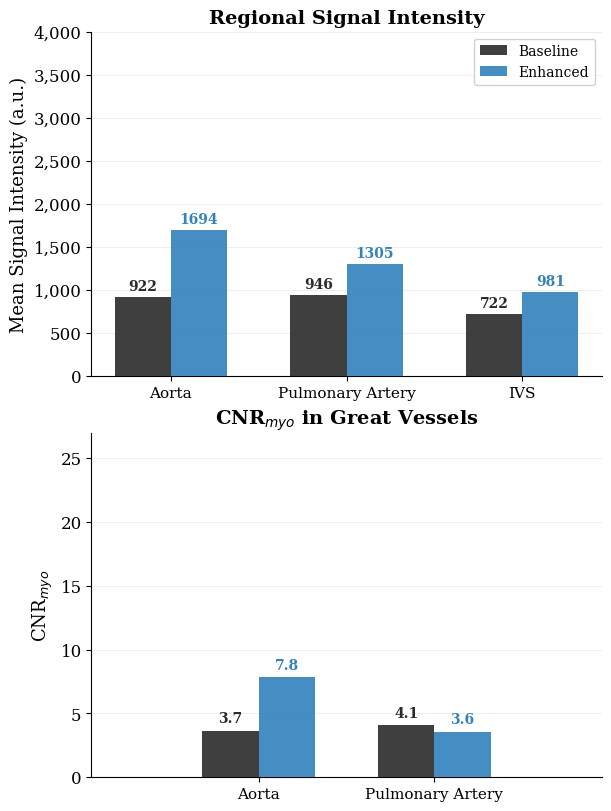

In [6]:
# ─── Per-patient metrics (stacked 2-row figure per patient) ──────────
import pandas as pd
import matplotlib.ticker as mticker

CSV_PATH = Path.home() / "vascular-superenhancement-4d-flow" / "notebooks" / "analysis" / "VSE_quantitative_analysis" / "consolidated.csv"
roi_data = pd.read_csv(CSV_PATH)

PATIENTS = ["Bomatog", "Gueshifa", "Diecudey", "Grequafie"]

BL_COLOR = "#2A2A2A"
EN_COLOR = "#3182bd"

SI_YLIM = (0, 4000)
CNR_YLIM = (0, 27)

PLOT_STYLE = {
    "font.family": "serif",
    "font.size": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}

regions_to_show = ["Ao", "PA", "IVS"]
REGION_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery", "IVS": "IVS"}
vessels = ["Ao", "PA"]
VESSEL_LABELS = {"Ao": "Aorta", "PA": "Pulmonary Artery"}
w = 0.32

def style_bar_labels(ax, x, bl_vals, en_vals, w, fmt=".0f", offset=0, fontsize=10):
    for i, (b, e) in enumerate(zip(bl_vals, en_vals)):
        ax.text(x[i] - w/2, b + offset, f"{b:{fmt}}", ha="center", va="bottom",
                fontsize=fontsize, fontweight="bold", color=BL_COLOR)
        ax.text(x[i] + w/2, e + offset, f"{e:{fmt}}", ha="center", va="bottom",
                fontsize=fontsize, fontweight="bold", color=EN_COLOR)

def get_cnr(pt_data, recon):
    sub = pt_data[pt_data["reconstruction"] == recon]
    ivs_mean = sub[sub["region"] == "IVS"]["mean"].mean()
    ivs_std = sub[sub["region"] == "IVS"]["std"].mean()
    return {v: (sub[sub["region"] == v]["mean"].mean() - ivs_mean) / ivs_std for v in vessels}

for pid in PATIENTS:
    pt_data = roi_data[roi_data["patient"] == pid]

    with plt.rc_context(PLOT_STYLE):
        fig, (ax_si, ax_cnr) = plt.subplots(2, 1, figsize=(6, 8), constrained_layout=True)

        # --- Top: Mean Signal Intensity ---
        x = np.arange(len(regions_to_show))
        bl_si, en_si = [], []
        for region in regions_to_show:
            bl = pt_data[(pt_data["region"] == region) & (pt_data["reconstruction"] == "normal")]
            en = pt_data[(pt_data["region"] == region) & (pt_data["reconstruction"] == "vse")]
            bl_si.append(bl["mean"].mean())
            en_si.append(en["mean"].mean())

        ax_si.bar(x - w/2, bl_si, w, color=BL_COLOR, alpha=0.9, label="Baseline", zorder=3)
        ax_si.bar(x + w/2, en_si, w, color=EN_COLOR, alpha=0.9, label="Enhanced", zorder=3)
        ax_si.set_xticks(x)
        ax_si.set_xticklabels([REGION_LABELS[r] for r in regions_to_show], fontsize=11)
        ax_si.set_ylabel("Mean Signal Intensity (a.u.)")
        ax_si.set_title("Regional Signal Intensity", fontweight="bold")
        ax_si.legend(fontsize=10, framealpha=0.9)
        ax_si.set_ylim(SI_YLIM)
        ax_si.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax_si.grid(axis="y", alpha=0.3, linewidth=0.5, zorder=0)
        style_bar_labels(ax_si, x, bl_si, en_si, w, fmt=".0f", offset=40)

        # --- Bottom: CNR_myo (centered within same x-range) ---
        bl_cnr = get_cnr(pt_data, "normal")
        en_cnr = get_cnr(pt_data, "vse")
        xv = np.array([0.5, 1.5])
        bl_vals = [bl_cnr[v] for v in vessels]
        en_vals = [en_cnr[v] for v in vessels]

        ax_cnr.bar(xv - w/2, bl_vals, w, color=BL_COLOR, alpha=0.9, zorder=3)
        ax_cnr.bar(xv + w/2, en_vals, w, color=EN_COLOR, alpha=0.9, zorder=3)
        ax_cnr.set_xticks(xv)
        ax_cnr.set_xticklabels([VESSEL_LABELS[v] for v in vessels], fontsize=11)
        ax_cnr.set_ylabel("CNR$_{myo}$")
        ax_cnr.set_title("CNR$_{myo}$ in Great Vessels", fontweight="bold")
        ax_cnr.set_ylim(CNR_YLIM)
        ax_cnr.set_xlim(ax_si.get_xlim())
        ax_cnr.grid(axis="y", alpha=0.3, linewidth=0.5, zorder=0)
        style_bar_labels(ax_cnr, xv, bl_vals, en_vals, w, fmt=".1f", offset=0.4)

    out_path = OUTPUT_DIR / f"si_cnr_{pid}.png"
    fig.savefig(out_path, dpi=200, bbox_inches="tight")
    print(f"Saved: {out_path}")
    plt.show()

Saved: thesis_figures/model_io_combined_Diecudey.png


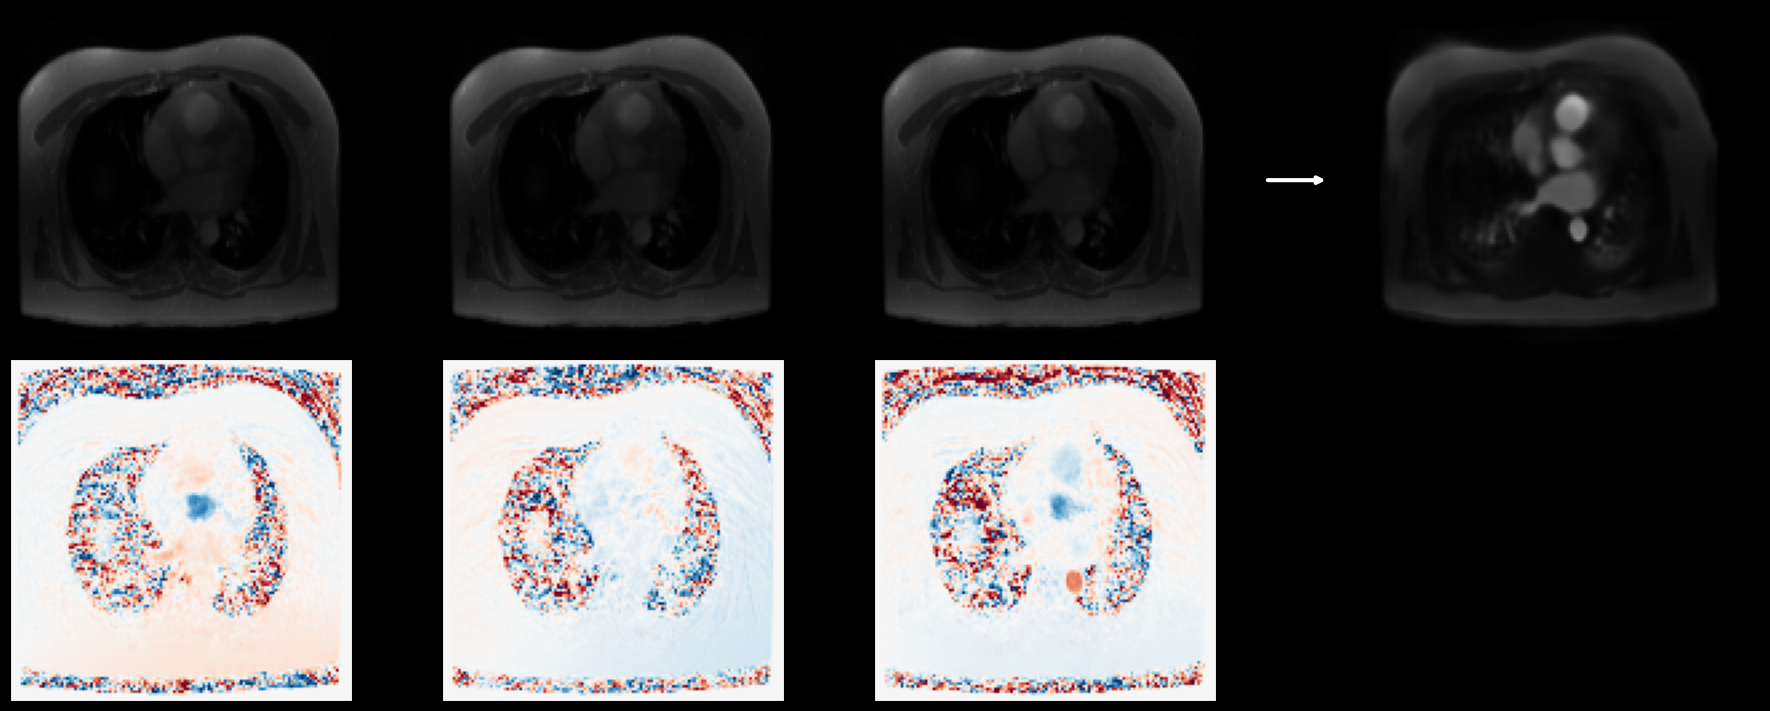

In [7]:
# ─── COMBINED: Inputs → Output side by side ──────────────────────────
# Single wide figure for a slide: 2 rows × 5 cols
# Row 1: mag(t-1) | mag(t) | mag(t+1) | gap | pred_cine
# Row 2: vx       | vy     | vz       | gap | (empty)

fig, axes = plt.subplots(
    2, 5, figsize=(18, 7),
    gridspec_kw={"width_ratios": [1, 1, 1, 0.15, 1]},
    constrained_layout=True,
)
fig.patch.set_facecolor("black")

# --- Left: Inputs ---
for ax, (label, data) in zip(axes[0, :3], mag_frames.items()):
    ax.imshow(data.T, origin="upper", cmap="gray", vmin=0, vmax=data.max() * MAG_VMAX_SCALE)

for ax, comp in zip(axes[1, :3], COMPONENTS):
    ax.imshow(
        vel_uncorr[comp].T, origin="upper", cmap=vel_cmap,
        vmin=-vel_scale, vmax=vel_scale,
    )

# --- Gap column with arrow ---
for row in range(2):
    axes[row, 3].set_facecolor("black")
    axes[row, 3].axis("off")
axes[0, 3].annotate(
    "", xy=(1, 0.5), xytext=(0, 0.5),
    xycoords="axes fraction", textcoords="axes fraction",
    arrowprops=dict(arrowstyle="->", color="white", lw=3),
)

# --- Right: Output ---
axes[0, 4].imshow(pred_mag.T, origin="upper", cmap="gray", vmin=0, vmax=1)

axes[1, 4].axis("off")
axes[1, 4].set_facecolor("black")

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])
    if not ax._frameon or ax.get_facecolor() != (0, 0, 0, 1):
        ax.set_facecolor("black")

out_path = OUTPUT_DIR / f"model_io_combined_{PID}.png"
fig.savefig(out_path, dpi=200, bbox_inches="tight", facecolor="black")
print(f"Saved: {out_path}")
plt.show()

## Tuning

- Change `PID` / `FRAME` to use a different patient or timepoint
- Override `z_idx` in cell 2 to pick a different axial slice
- Override `vel_scale` / `corr_scale` to adjust colour range
- `INFERENCE_RUN` controls which model's predictions are shown (default: `glowing-microwave_epoch-69`)